# Evaluating LLM-as-a-Judge Reliability for Customer Support

## Research Question

Can an efficiency-oriented language model reliably perform criterion-level
customer-support quality evaluation against an established benchmark while
remaining operationally cost-effective?

This experiment evaluates GPT-5.6 Luna against reference labels from the
Sprinklr CXM Arena `Agent_Quality_Adherence` dataset.

The analysis focuses on four questions:

1. How closely do the model's judgments agree with the benchmark reference labels?
2. Does performance differ between `Yes` and `No` evaluation cases?
3. What recurring failure patterns appear when the model and benchmark disagree?
4. What do the observed reliability and inference costs imply for practical deployment?

## Dataset Preparation

This project uses the Sprinklr CXM Arena `Agent_Quality_Adherence` dataset from Hugging Face.

### Dataset structure

Initial exploration identified three levels of data:

- **1,987 unique customer-support conversations**
- **5,199 evaluation sets** associated with those conversations
- **17,762 individual evaluation judgments**

Each evaluation judgment contains:
- a customer-agent conversation
- an evaluation question
- a binary ground-truth label (`Yes` or `No`)
- an explanation supporting the label
- proof message IDs when available
- a confidence score

The source data was flattened so that each row represents one unique
`conversation_id + evaluation question` pair. No duplicate pairs were found.

### Evaluation sample

To prevent repeated conversations from appearing in the test set, one evaluation judgment was randomly selected from each unique conversation using `random_state=42`.

This produced a candidate pool of **1,987 independent conversations**:
- 1,250 `Yes`
- 737 `No`

From this pool, a reproducible stratified sample of **100 evaluation cases** was created:
- 50 `Yes`
- 50 `No`

The balanced test set was intentionally selected so that a judge cannot achieve deceptively high accuracy by disproportionately predicting the majority class.

### Leakage prevention

The LLM judge will receive only:
- `conversation_id`
- `conversation`
- `question`

The ground-truth label, reference explanation, proof message IDs, and confidence score are withheld from the judge and retained separately for post-evaluation comparison.

In [1]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset(
    "sprinklr-huggingface/CXM_Arena",
    "Agent_Quality_Adherence"
)

In [2]:
import json

# Convert the Hugging Face dataset to a pandas DataFrame
df = dataset["train"].to_pandas()

# Parse the nested evaluation records
df["parsed_questions"] = df["question_answers"].apply(json.loads)

In [3]:
evaluation_rows = []

for _, row in df.iterrows():
    for evaluation in row["parsed_questions"]:
        evaluation_rows.append({
            "conversation_id": row["conversation_id"],
            "conversation": row["conversation"],
            "question": evaluation["Question"],
            "ground_truth": evaluation["Answer"],
            "explanation": evaluation["Explanation"],
            "proof_message_ids": evaluation["proof_message_ids"],
            "confidence_score": evaluation["confidence_score"]
        })

eval_df = pd.DataFrame(evaluation_rows)

print(f"Evaluation judgments: {len(eval_df):,}")
print(f"Unique conversations: {eval_df['conversation_id'].nunique():,}")

Evaluation judgments: 17,762
Unique conversations: 1,987


In [4]:
# Verify each conversation-question pair is unique
duplicate_pairs = eval_df.duplicated(
    subset=["conversation_id", "question"]
).sum()

# Select one evaluation criterion per unique conversation
one_per_conversation = (
    eval_df
    .groupby("conversation_id")
    .sample(n=1, random_state=42)
)

# Create a balanced 100-case evaluation sample
eval_sample = (
    one_per_conversation
    .groupby("ground_truth", group_keys=False)
    .sample(n=50, random_state=42)
)

print(f"Duplicate conversation-question pairs: {duplicate_pairs}")
print(f"Candidate conversations: {len(one_per_conversation):,}")
print("\nEvaluation sample:")
print(eval_sample["ground_truth"].value_counts())

Duplicate conversation-question pairs: 0
Candidate conversations: 1,987

Evaluation sample:
ground_truth
No     50
Yes    50
Name: count, dtype: int64


In [5]:
from pathlib import Path

# Save the frozen evaluation sample
Path("../data").mkdir(exist_ok=True)

eval_sample.to_json(
    "../data/evaluation_sample.jsonl",
    orient="records",
    lines=True
)

# Reload the frozen sample used for inference
saved_sample = pd.read_json(
    "../data/evaluation_sample.jsonl",
    lines=True
)

# Create leakage-safe model input
judge_input = saved_sample[
    ["conversation_id", "conversation", "question"]
].copy()

print(f"Frozen evaluation cases: {len(saved_sample)}")
print(f"Fields provided to judge: {list(judge_input.columns)}")

Frozen evaluation cases: 100
Fields provided to judge: ['conversation_id', 'conversation', 'question']


## Evaluation Design

The LLM judge evaluates each case using the same system instructions and prompt
structure. The judge receives the complete customer-support conversation and one
evaluation criterion, but does not receive the CXM Arena reference label,
reference explanation, proof message IDs, or confidence score.

The prompt instructs the judge to evaluate only the behavior described by the
criterion and to return a binary `Yes` or `No` judgment with a brief explanation.

The prompt was held constant throughout the 100-case evaluation and was not
modified in response to individual test-set disagreements.

In [6]:
JUDGE_SYSTEM_PROMPT = """
You are evaluating the quality of a customer-support interaction.

You will receive:
1. A conversation between a customer and an agent.
2. One evaluation question about the agent's behavior.

Evaluate only the behavior asked about in the evaluation question.

Return:
- "Yes" if the conversation provides sufficient evidence that the agent satisfied the criterion.
- "No" if the agent did not satisfy the criterion or there is insufficient evidence that they did.

Base your judgment only on the conversation provided.
Do not assume actions or information that are not present in the conversation.
"""

In [7]:
def build_judge_prompt(row):
    return f"""
Conversation:
{row["conversation"]}

Evaluation question:
{row["question"]}

Return your response in this format:
{{
    "judgment": "Yes" or "No",
    "explanation": "Brief explanation of your judgment"
}}
"""

## Model Selection

GPT-5.6 Luna (`gpt-5.6-luna`) was selected as the LLM judge for this experiment.

The evaluation task is narrowly scoped: given a complete customer-support
conversation and one explicit behavioral criterion, the model must return a
binary `Yes` or `No` judgment with a brief explanation.

GPT-5.6 Luna is optimized for cost-sensitive, high-volume workloads, making it
a useful candidate for testing whether an efficiency-oriented model can perform
reliable customer-support quality evaluation at scale.

Rather than assuming that a more expensive model is necessary for LLM-as-a-judge
workflows, this experiment tests whether a lower-cost model can achieve sufficient
agreement with human-generated reference labels on a constrained evaluation task.

This reflects a practical deployment question for businesses considering automated
customer-support QA: can reliable criterion-level evaluation be achieved at a cost
that makes high-volume evaluation operationally practical?

The experiment will evaluate:
- agreement with CXM Arena reference labels
- performance on `Yes` versus `No` cases
- disagreement and failure patterns
- API cost
- operational reliability

In [8]:
from dotenv import load_dotenv
import os

load_dotenv("../.env")

api_key = os.getenv("OPENAI_API_KEY")

print("API key loaded:", api_key is not None)

API key loaded: True


In [9]:
from openai import OpenAI

client = OpenAI(api_key=api_key)

In [10]:
def judge_case(row):
    response = client.responses.create(
        model="gpt-5.6-luna",
        instructions=JUDGE_SYSTEM_PROMPT,
        input=build_judge_prompt(row)
    )

    result = json.loads(response.output_text)

    return {
        "judgment": result["judgment"],
        "explanation": result["explanation"],
        "input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens,
        "total_tokens": response.usage.total_tokens
    }

In [11]:
evaluation_results = []

## Experiment Execution

The frozen evaluation sample contained 100 customer-support cases, with one
evaluation judgment selected per unique conversation and an equal distribution
of `Yes` and `No` reference labels.

For each case, the judge received only:
- the complete customer-agent conversation
- the evaluation question

The CXM Arena reference label, reference explanation, proof message IDs,
and confidence score were withheld during inference.

Each case was evaluated independently using the same system prompt and model
configuration. The pipeline recorded:
- the model's `Yes` or `No` judgment
- the model-generated explanation
- input token usage
- output token usage
- total token usage

Reference labels were compared with model judgments only after inference was
complete. The prompt was not modified in response to individual test-set results.

To keep the analysis reproducible without triggering additional API calls, this
notebook loads the saved outputs from the completed 100-case experiment for
scoring and analysis. The inference function above documents how those outputs
were generated.

In [12]:
# Load the completed 100-case experiment results
results_df = pd.read_json(
    "../results/evaluation_results.jsonl",
    lines=True
)

print(f"Completed evaluations: {len(results_df)}")

Completed evaluations: 100


In [13]:
scored_df = results_df.copy()

In [14]:
scored_df["correct"] = (
    scored_df["judgment"] == scored_df["ground_truth"]
)

accuracy = scored_df["correct"].mean()

accuracy

np.float64(0.84)

In [15]:
pd.crosstab(
    scored_df["ground_truth"],
    scored_df["judgment"],
    rownames=["CXM Ground Truth"],
    colnames=["Luna Judgment"]
)

Luna Judgment,No,Yes
CXM Ground Truth,,
No,42,8
Yes,8,42


In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
        scored_df["ground_truth"],
        scored_df["judgment"],
        labels=["Yes", "No"]
    )
)

              precision    recall  f1-score   support

         Yes       0.84      0.84      0.84        50
          No       0.84      0.84      0.84        50

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



In [17]:
from pathlib import Path

Path("../results").mkdir(exist_ok=True)

scored_df.to_json(
    "../results/evaluation_results.jsonl",
    orient="records",
    lines=True
)

## Cost Analysis

Token usage was recorded for each API request during the 100-case evaluation.
This allows the experiment's actual inference usage to be measured and used to
estimate the operational cost of running the judge at larger volumes.

### Estimated Inference Cost

The 100-case evaluation consumed:

- **141,815 input tokens**
- **12,068 output tokens**
- **153,883 total tokens**

At the GPT-5.6 Luna standard API rates used at the time of the experiment
($0.20 per 1M uncached input tokens and $1.20 per 1M output tokens), the
recorded token usage produces an upper-bound simple inference estimate of
approximately **$0.043 for 100 evaluations**, assuming all recorded input
tokens were billed at the uncached input rate.

Actual inference cost may have been lower because GPT-5.6 Luna provides
discounted pricing for cached input tokens. Cached-token usage was observed
during development but was not recorded for each evaluation request, so an
exact cache-adjusted cost cannot be reconstructed from the saved experiment
results.

The API project dashboard showed approximately **$0.05 in total spend** after
the experiment and associated development/test calls, which is consistent
with the token-based estimate.

These results suggest that inference cost was not the primary constraint in
this experiment. The more significant deployment consideration was evaluation
reliability, particularly the rubric-interpretation and evidence-standard
disagreements identified during error analysis.

In [18]:
token_totals = scored_df[
    ["input_tokens", "output_tokens", "total_tokens"]
].sum()

token_totals

input_tokens     141815
output_tokens     12068
total_tokens     153883
dtype: int64

In [19]:
average_tokens = token_totals / len(scored_df)

average_tokens

input_tokens     1418.15
output_tokens     120.68
total_tokens     1538.83
dtype: float64

## Disagreement Analysis

To understand where the LLM judge failed, cases where the model judgment
disagreed with the CXM Arena reference label were isolated for qualitative
analysis.

The goal is to identify recurring disagreement patterns rather than treating
accuracy alone as sufficient evidence of judge reliability.

In [20]:
disagreements = scored_df[
    scored_df["correct"] == False
].copy()

disagreements.shape

(16, 9)

In [21]:
disagreements = disagreements.merge(
    saved_sample[
        ["conversation_id", "explanation"]
    ].rename(columns={"explanation": "cxm_explanation"}),
    on="conversation_id",
    how="left"
)

disagreements.shape

(16, 10)

In [22]:
pd.set_option("display.max_colwidth", 300)

disagreements[
    [
        "conversation_id",
        "question",
        "ground_truth",
        "judgment",
        "cxm_explanation",
        "explanation"
    ]
]

,conversation_id,question,ground_truth,judgment,cxm_explanation,explanation
0,1828,"When a product issue related to specifications was reported, did the agent offer both an explanation and a solution?",No,Yes,"The agent attempted to troubleshoot the thermostat issue by suggesting power cycling, firmware updates, and recreating automation rules. However, the agent did not provide a detailed explanation of why the thermostat was not following the automation rules.","The agent offered possible explanations, such as a software glitch, configuration issue, or rule conflict, and provided solutions including updating firmware, recreating rules, simplifying schedules, and contacting technical support."
1,1075,"When the customer's issue or changes suggested a contributing factor (e.g., air filtration changes), did the agent gather relevant details?",No,Yes,The agent did not gather details about potential contributing factors like air filtration changes. The focus was on vacuuming and rug maintenance.,"The agent gathered relevant details about the shedding, including the vacuum type, vacuuming frequency, and use of the beater bar, which was identified as a contributing factor. They also asked about heavy objects affecting uneven pile areas."
2,1343,"When the customer described an issue, did the agent gather details about potentially relevant environmental factors?",No,Yes,"The agent did not gather details about potentially relevant environmental factors. The focus was on verifying the recycled content discrepancy and offering remediation options, not on environmental factors.","The agent gathered relevant environmental details by asking about the sustainability claim, specifically the recycled content percentage, certification concerns, and the product batch number."
3,226,"When the customer described a scenario, did the agent confirm relevant specifications or parameters?",No,Yes,"The agent confirmed the environmental conditions and the sealant used, but did not confirm specific product specifications or parameters related to the scenario.","The agent confirmed relevant specifications by asking about the lumber product, installation process, environmental conditions, maintenance, and the specific sealant used, then checking its compatibility with FSC-Certified Redwood."
4,546,"Based on the customer's description, did the agent verify relevant settings for optimal performance?",No,Yes,The agent did not verify any specific settings for optimal performance. The focus was on environmental factors and operational advice.,"The agent verified relevant operating conditions by asking about ambient temperature, direct sunlight exposure, and continuous runtime, all of which can affect pump overheating and performance."
5,1214,"When the agent could not resolve the issue, did they escalate it appropriately?",No,Yes,"The agent repeatedly mentioned escalating the issue to a supervisor. However, the repeated messages and lack of progress suggest that the escalation process was not handled effectively.","The agent explicitly stated multiple times that the WaterSense certification issue had been escalated to a supervisor for further investigation, although they did not provide a supervisor response."
6,744,"After recommending corrective actions, did the agent follow up to confirm resolution and gather relevant information?",No,Yes,The agent did not explicitly follow up to confirm if the customer had resolved the issue after recommending corrective actions. The conversation ended without a follow-up on resolution.,"The agent gathered relevant information by asking about the primer type and water- or oil-based composition, then confirmed the corrective plan when the customer restated the steps."
7,844,"When the customer reported or suspected a component-related issue, did the agent guide the customer through a relevant inspection or examination of the component?",No,Yes,The agent did not guide the customer through an inspection or examination of a specifi

In [23]:
case = disagreements.iloc[15]

print("QUESTION:")
print(case["question"])

print("\nCXM GROUND TRUTH:")
print(case["ground_truth"])

print("\nLUNA JUDGMENT:")
print(case["judgment"])

print("\nCXM REASONING:")
print(case["cxm_explanation"])

print("\nLUNA REASONING:")
print(case["explanation"])

QUESTION:
When a mistake or shortcoming occurred, did the agent acknowledge it and explain the next steps?

CXM GROUND TRUTH:
Yes

LUNA JUDGMENT:
No

CXM REASONING:
The agent acknowledged the failed audit by GreenFiber Textiles and explained the next steps, which included corrective actions and identifying alternative suppliers.

LUNA REASONING:
When the customer pointed out that the agent was repeating itself, the agent did not acknowledge the mistake. They only stated that they would contact suppliers and provide an update.


### Manual Error Review

The 16 cases where the LLM judge disagreed with the CXM Arena reference label
were manually reviewed to identify potential sources of disagreement.

For each case, the review recorded:
- error type (`False Positive` or `False Negative`)
- a qualitative failure category
- a reviewer note describing the observed disagreement

Failure categories were developed iteratively from the observed cases rather
than defined in advance. Case-level annotations were stored separately in
`results/error_analysis.csv` and loaded back into the notebook for aggregate
analysis.

These categories describe observed disagreement patterns and do not assume
that every reference label represents an objectively correct interpretation.

In [24]:
error_analysis = pd.read_csv("../results/error_analysis.csv")

error_analysis["failure_category"].value_counts()

failure_category
Scope interpretation mismatch              5
Criterion threshold mismatch               4
Evidence standard mismatch                 3
Incomplete multi-part criterion            1
Extraneous context influence               1
Conditional criterion misinterpretation    1
Event attribution mismatch                 1
Name: count, dtype: int64

### Failure Patterns by Error Type

Failure categories were compared across false positives and false negatives to
determine whether particular disagreement patterns were associated with the
judge being more permissive or more restrictive than the reference labels.

In [25]:
pd.crosstab(
    error_analysis["failure_category"],
    error_analysis["error_type"]
)

error_type,False Negative,False Positive
failure_category,,
Conditional criterion misinterpretation,1,0
Criterion threshold mismatch,2,2
Event attribution mismatch,1,0
Evidence standard mismatch,3,0
Extraneous context influence,1,0
Incomplete multi-part criterion,0,1
Scope interpretation mismatch,0,5


### Error Analysis Findings

Manual review of the 16 disagreements revealed that errors were concentrated
around rubric interpretation rather than obvious failures to identify
conversation content.

The most common failure mode was **scope interpretation mismatch** (5 of 16
disagreements), and all five cases were false positives. In these cases, the
judge identified relevant evidence in the conversation but applied the
evaluation criterion too broadly.

**Criterion threshold mismatch** accounted for 4 of 16 disagreements and
occurred equally across false positives and false negatives. This suggests that
the judge and reference labels sometimes applied different standards for how
much or what quality of evidence was sufficient to satisfy a criterion.

**Evidence standard mismatch** accounted for 3 of 16 disagreements, all false
negatives. In these cases, the judge required more explicit evidence that an
action had occurred, while the reference label accepted statements or other
indirect evidence as sufficient.

The remaining four disagreements represented single-instance patterns involving
a multi-part criterion, conditional criterion, extraneous conversational
context, and attribution of the criterion to different events.

Overall, the disagreement analysis suggests that judge reliability depends not
only on conversation comprehension, but also on how precisely evaluation
criteria define scope, sufficiency, conditional requirements, and acceptable
evidence.

## Deployment Implications

The experiment achieved 84% agreement with the CXM Arena reference labels,
with balanced performance across `Yes` and `No` cases. However, the qualitative
error analysis indicates that overall agreement alone is not sufficient to
support fully autonomous use of the judge.

The observed disagreements suggest several implementation considerations:

1. **Define rubric boundaries explicitly.**  
   The most common false-positive pattern occurred when the judge interpreted
   evaluation criteria more broadly than the reference labels. Production
   rubrics should clearly define what evidence does and does not satisfy each
   criterion.

2. **Decompose compound criteria.**  
   Criteria containing multiple requirements should be evaluated as separate,
   atomic behaviors where possible. This reduces the risk of the judge awarding
   credit after observing only one component of a multi-part requirement.

3. **Define acceptable evidence standards.**  
   The system should explicitly specify whether an agent's statement that an
   off-transcript action occurred is sufficient, or whether external system
   evidence is required to verify actions such as escalation or document
   delivery.

4. **Clarify conditional language.**  
   Terms such as "when applicable," "when appropriate," and similar conditions
   should include explicit decision rules so the judge can determine when a
   requirement applies.

5. **Use human review for ambiguous cases.**  
   Given the observed disagreement rate and the concentration of errors around
   rubric interpretation, the judge would be better suited to a human-in-the-loop
   workflow than fully autonomous quality scoring without additional validation.

These findings suggest that improving judge reliability is not solely a model
selection problem. Evaluation design, rubric construction, evidence standards,
and escalation logic are also important components of a production-quality
LLM evaluation system.

## Results Visualization

The confusion matrix below shows the distribution of agreement and disagreement
between the LLM judge and the CXM Arena reference labels across the balanced
100-case evaluation sample.

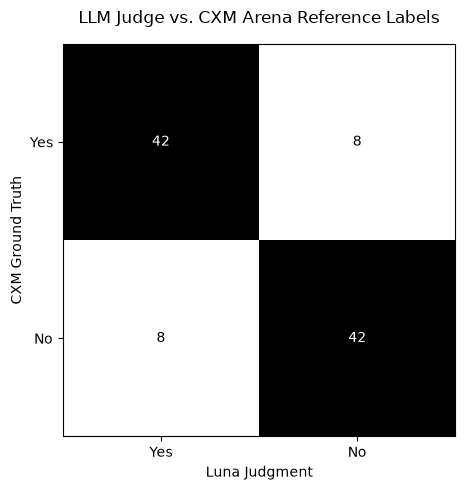

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    scored_df["ground_truth"],
    scored_df["judgment"],
    labels=["Yes", "No"],
    cmap="Greys",
    colorbar=False,
    ax=ax
)

ax.set_title(
    "LLM Judge vs. CXM Arena Reference Labels",
    fontsize=12,
    pad=15
)

ax.set_xlabel("Luna Judgment")
ax.set_ylabel("CXM Ground Truth")

plt.tight_layout()
plt.savefig("../results/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

### Distribution of Disagreement Patterns

The chart below summarizes the qualitative failure categories identified during
manual review of the 16 disagreements.

In [27]:
error_analysis["failure_category"].value_counts(dropna=False)

failure_category
Scope interpretation mismatch              5
Criterion threshold mismatch               4
Evidence standard mismatch                 3
Incomplete multi-part criterion            1
Extraneous context influence               1
Conditional criterion misinterpretation    1
Event attribution mismatch                 1
Name: count, dtype: int64

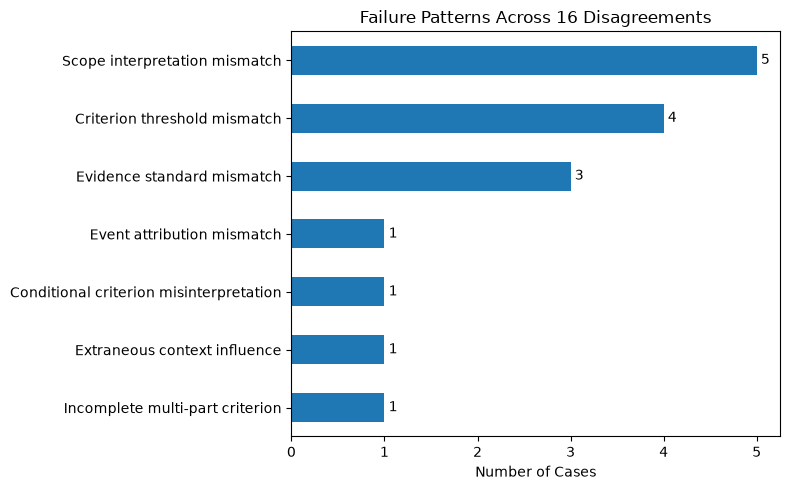

In [30]:
failure_counts = (
    error_analysis["failure_category"]
    .value_counts()
    .sort_values()
)

ax = failure_counts.plot(
    kind="barh",
    figsize=(8, 5)
)

ax.set_title("Failure Patterns Across 16 Disagreements")
ax.set_xlabel("Number of Cases")
ax.set_ylabel("")

ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.savefig("../results/failure_patterns.png", dpi=300, bbox_inches="tight")
plt.show()

## Limitations

This experiment was designed as a focused evaluation of LLM-as-a-judge
reliability and has several limitations.

- **Sample size:** The evaluation used 100 cases from a larger benchmark.
  Results should therefore be interpreted as evidence from this sample rather
  than a comprehensive estimate of performance across all CXM Arena cases.

- **Balanced test set:** The sample was intentionally balanced to contain
  50 `Yes` and 50 `No` reference labels. This supports comparison across both
  classes but does not reflect the original label distribution of the dataset.

- **One criterion per conversation:** Only one evaluation criterion was sampled
  from each unique conversation. Performance may differ across other criteria
  associated with the same conversations.

- **Reference-label uncertainty:** Agreement with the CXM Arena reference labels
  does not necessarily represent objective correctness. Manual error analysis
  identified cases where the model and reference appeared to apply different
  interpretations or evidence standards.

- **Prompt sensitivity:** Results reflect one judge prompt and one model
  configuration. Different rubric wording, prompt design, or model selection
  could produce different results.

- **Output enforcement:** The experiment requested JSON-formatted responses
  through prompting but did not enforce a structured output schema. All 100
  responses in this run were successfully parsed, but a production system
  should include schema enforcement, validation, retries, and error handling.

- **Operational validation:** The experiment measured benchmark agreement and
  token usage but did not test the judge in a live customer-support environment.
  Production deployment would require additional validation using
  organization-specific conversations, rubrics, policies, and workflows.

## Conclusion

This experiment evaluated whether an efficiency-oriented LLM could reliably
perform criterion-level customer-support quality evaluation against CXM Arena
reference labels.

Across a balanced sample of 100 unique customer-support conversations, the LLM
judge achieved **84% agreement** with the reference labels. Performance was
symmetric across both classes, with 42 of 50 `Yes` cases and 42 of 50 `No`
cases classified in agreement with the benchmark.

However, manual review of the 16 disagreements showed that aggregate accuracy
did not capture the most important reliability issue. The dominant failure
patterns involved interpretation of the evaluation rubric rather than obvious
failures to identify conversation content.

Scope interpretation, criterion thresholds, and evidence standards accounted
for 12 of the 16 observed disagreements. False positives were particularly
associated with overly broad interpretations of criterion scope, while several
false negatives occurred when the judge required more explicit evidence than
the reference labels.

Based on these results, the tested configuration shows potential for assisting
with high-volume customer-support evaluation, but the observed disagreement
patterns do not support treating the judge as a fully autonomous replacement
for human quality review.

A stronger production design would use more explicit and atomic evaluation
criteria, clearly defined evidence standards, structured output enforcement,
and human review for ambiguous or consequential judgments. Additional
validation on organization-specific data would be necessary before deployment.

The experiment also demonstrates that LLM-as-a-judge reliability is not solely
a model-selection problem. The design of the evaluation rubric itself can
materially affect judge behavior and should be treated as part of the AI system.